In [16]:
import os
import sys
import glob
import pandas as pd
import numpy as np
from pathlib import Path
sys.path.append("..")

root = Path.cwd().parent

from utils.common import load_data_and_info
from evaluation.fidelity import get_positive_train, mixed_mmd

In [17]:
from process.ifc_analysis_utils import *

generation_table = build_artifacts_path_table(data_root=root/"experiments")

train_table = build_original_data_path_table(data_root=root/"experiments")

In [28]:
generation_table = generation_table[~((generation_table['mix_ratio']=="mix_37_235"))]

### 1. 计算和原始训练数据集的MMD距离

In [29]:
results = []

for _, gen_row in generation_table.iterrows():
    dataset = gen_row.Dataset
    _, _, _, num_cols, cat_cols, _, datasets_info = load_data_and_info(dataset)

    seed = gen_row.Seed
    fold = gen_row.Fold

    # 找对应train
    train_row = train_table[(train_table.Dataset==dataset)&(train_table.Seed==seed)&(train_table.Fold==fold)].iloc[0]
    X_real = get_positive_train(train_row)
    X_fake = pd.read_parquet(gen_row.fidelity_path)

    score = mixed_mmd(X_real,X_fake,num_cols,cat_cols)

    results.append(
        {"Dataset":dataset, "Seed":seed, "Fold":fold, "Method":gen_row.Method, "prior_type":gen_row.prior_type,
        "finetune":gen_row.finetune, "stage_depth":gen_row.stage_depth, "MMD":score}
        )

mmd_results = pd.DataFrame(results)

### 2. 统计 seedxfold 组合的均值和方差

In [30]:
mmd_summary = (
    mmd_results.groupby(["Dataset", "Method", "prior_type", "finetune", "stage_depth"], dropna=False)
    ["MMD"].agg(["mean", "std"]).reset_index())


dataset_mapping = {
    "breast_cancer_coimbra": "BCC",
    "PIMA_diabetes": "PIMA",
    "TCGA_InfoWithGrade": "TCGA",
    "Thyroid_Diff": "THY",
    "diabetes_risk_prediction": "DRP",
    "framingham": "FRM",
    "hepatitis": "HEP"
}

method_mapping = {
    "bootstrap_noft_d2":"B-NoFT-d2",
    "bootstrap_noft_d3":"B-NoFT-d3",
    "bootstrap_ft_d2":"B-FT-d2",
    "bootstrap_ft_d3":"B-FT-d3",
    "smote_noft_d2":"S-NoFT-d2",
    "smote_noft_d3":"S-NoFT-d3",
    "smote_ft_d2":"S-FT-d2",
    "smote_ft_d3":"S-FT-d3",
    "none_noft":"None-NoFT",
    "none_ft":"None-FT"
}

In [31]:
import pandas as pd
import numpy as np


def method_label(row):
    # baseline
    if pd.isna(row["prior_type"]):
        return row["Method"]
    # IFC
    method = row["Method"]
    if method in ["none_noft", "none_ft"]:
        return method
    depth = int(row["stage_depth"])
    return f"{method}_d{depth}"

plot_df = mmd_summary.copy()
plot_df["Method_label"] = plot_df.apply(method_label, axis=1)

heatmap_df = (plot_df.pivot_table( index="Method_label", columns="Dataset", values="mean", aggfunc="mean"))

In [32]:
method_order = [
    # baseline
    "smote", "ctgan", "tvae", "forestdiffusion", "tabddpm", "tabkde",
    # IFC
    "none_noft", "none_ft",
    "bootstrap_noft_d2", "bootstrap_noft_d3",
    "bootstrap_ft_d2", "bootstrap_ft_d3",
    "smote_noft_d2", "smote_noft_d3",
    "smote_ft_d2", "smote_ft_d3",
]

available_methods = [x for x in method_order if x in heatmap_df.index]
heatmap_df = heatmap_df.loc[available_methods]

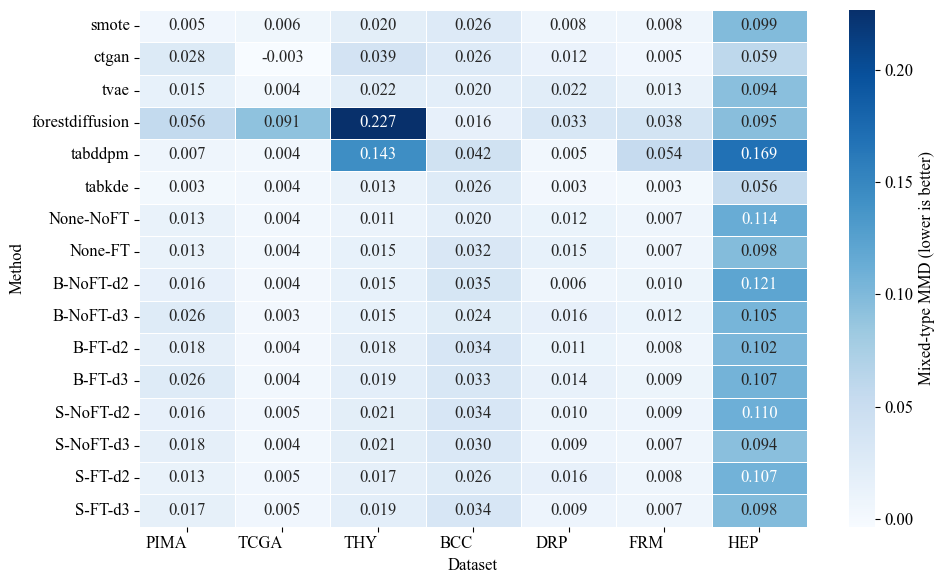

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

heatmap_df_plot = heatmap_df.copy()
heatmap_df_plot.index = [method_mapping.get(x, x) for x in heatmap_df_plot.index]
heatmap_df_plot.columns = [dataset_mapping.get(x, x) for x in heatmap_df_plot.columns]

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df_plot, annot=True, fmt=".3f", cmap="Blues", linewidths=0.5,
    cbar_kws={"label": "Mixed-type MMD (lower is better)"})

plt.xlabel("Dataset")
plt.ylabel("Method")
plt.xticks(rotation=0, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('mmd_heatmap.pdf', bbox_inches='tight')
plt.show()

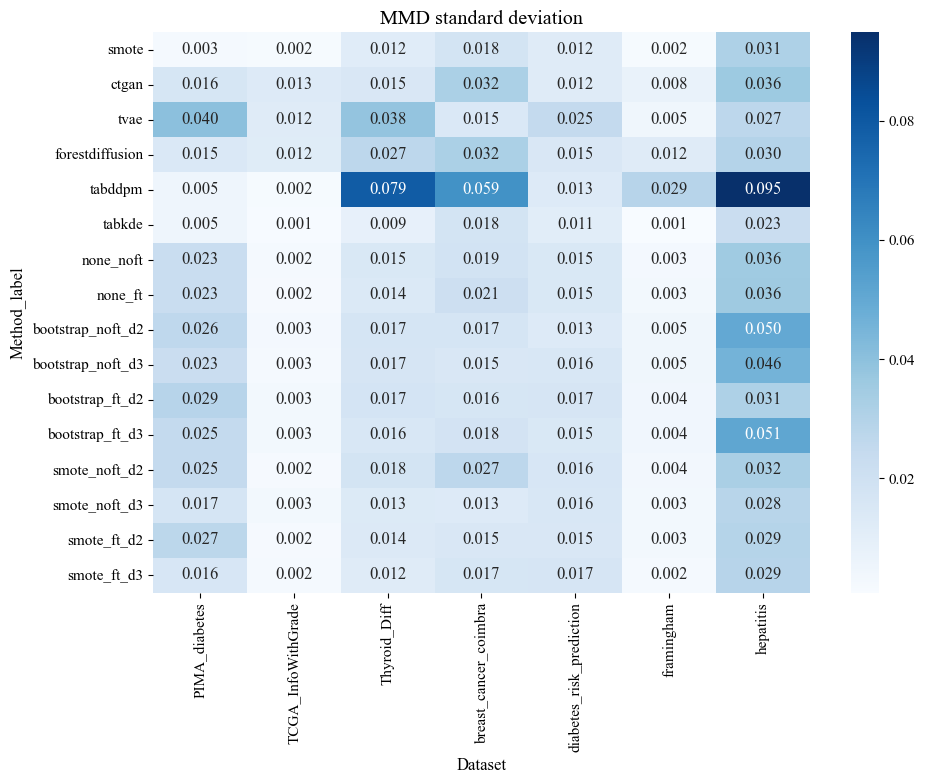

In [46]:
std_heatmap = (plot_df.pivot_table(
    index="Method_label", columns="Dataset", values="std", aggfunc="mean"))

std_heatmap = std_heatmap.loc[available_methods]
plt.figure(figsize=(10,8))
sns.heatmap(std_heatmap, annot=True, fmt=".3f", cmap="Blues")
plt.title("MMD standard deviation")
plt.tight_layout()
plt.show()